# Encode causality vào model — thử năm hướng và đo cái giá

> **Mentor nói:** *"Anh nghĩ **encode được causality info này vào 1 model** sẽ khá là tốt trong việc
> improve accuracy hay uncertainty."*

`03` và `05` đã đo **giá phản ứng thế nào** với từng yếu tố. Notebook này làm bước tiếp theo: **đưa
thông tin đó vào model** và đo xem được gì, mất gì.

## Vấn đề xuất phát

`03_CETERIS_PARIBUS_VA_CAUSALITY` phát hiện một khoảng cách 9 điểm:

| Đo gì | Kết quả |
|---|---:|
| Giá **thực tế** đổi khi mưa (ghép cặp) | **+9,98%** |
| Model **quy cho bản thân việc trời mưa** (partial dependence) | **+0,93%** |

Cách đọc ban đầu: *model dùng đường tắt — nó chép giá đối thủ quan sát ở thời điểm trễ thay vì hiểu
mưa*. Notebook này kiểm cách đọc đó bằng cách **rút đường tắt ra và train lại**.

Kết quả không như dự đoán, và phần chẩn đoán ở mục 5 mới là nội dung đáng giá nhất.

## Ba thước đo, không phải một

| Thước đo | Là gì | Muốn |
|---|---|---|
| **MAE / MAPE** | Độ chính xác trên tập test | càng thấp càng tốt |
| **Nửa độ rộng khoảng** | Uncertainty ở mức tin cậy 90% | càng hẹp càng tốt |
| **Khoảng cách PDP** | Chênh giữa *model nói* và *thực tế* | càng gần 0 càng tốt |

> ⚠️ **Dữ liệu synthetic.** Mọi biến thể train bằng **cùng một cấu hình LightGBM** để so sánh công
> bằng, nên số tuyệt đối lệch nhẹ so với model production (HistGB có early stopping). Cái cần đọc là
> **chênh lệch giữa các biến thể**.

In [1]:
import warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from pathlib import Path
%matplotlib inline

BASE, MULT, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                       "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
DATA = Path("../data/hcm_train_ready.parquet")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

CAT = ["service_name", "pickup_location_name", "dropoff_location_name", "weather_main"]
NUM = ["quote_distance", "quote_duration", "gio_vn", "latest_observed_price",
       "latest_observed_multiplier", "history_60m_price_mean", "history_60m_price_std",
       "history_60m_price_slope_per_minute", "latest_observed_quote_distance",
       "latest_observed_quote_duration", "actual_observation_age_minutes",
       "pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag",
       "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag"]
KHAC = ["split", "requested_lag_minutes", "target_shown_price", "target_shown_multiplier",
        "target_is_weekend"]

d = pd.read_parquet(DATA, columns=CAT + NUM + KHAC)
d["lob"] = d.latest_observed_price / d.latest_observed_multiplier   # gia co ban quan sat
d["base_that"] = d.target_shown_price / d.target_shown_multiplier
d["heso_that"] = d.target_shown_multiplier
d["cuoi_tuan"] = d.target_is_weekend.astype(bool)
for c in CAT:
    d[c] = d[c].astype("category")          # dat danh muc 1 lan tren df day du

tr   = d[d.split == "train"]
cal  = d[(d.split == "calibration") & (d.requested_lag_minutes == 5)]
te   = d[(d.split == "test")        & (d.requested_lag_minutes == 5)].copy()
tr30 = tr[tr.requested_lag_minutes == 30]

print(f"train {len(tr):,} · calibration {len(cal):,} · test {len(te):,}")
print(f"train lag 30′ (cho biến thể D): {len(tr30):,}")

train 4,641,799 · calibration 153,977 · test 216,090
train lag 30′ (cho biến thể D): 1,159,781


## 1. Bộ feature và hai nhóm cần chú ý

Ngoài bộ feature production, tài liệu này tách riêng **hai nhóm** sẽ đóng vai chính ở mục 5:

| Nhóm | Feature | Vì sao đặc biệt |
|---|---|---|
| **Đường tắt** | `lob`, `latest_observed_multiplier`, `history_60m_*` | Giá đối thủ quan sát ở thời điểm trễ — đã chứa sẵn phản ứng của thị trường |
| **Trung gian** | `pricing_demand_index`, `supply_index`, `market_imbalance`, `quote_count` | Tín hiệu cung–cầu — **mưa tác động lên giá thông qua chính nhóm này** |

In [2]:
B_NUM = ["quote_distance", "quote_duration", "gio_vn", "lob",
         "history_60m_price_mean", "history_60m_price_std",
         "history_60m_price_slope_per_minute", "latest_observed_quote_distance",
         "latest_observed_quote_duration", "actual_observation_age_minutes"]
M_NUM = ["pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag",
         "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag",
         "latest_observed_multiplier", "gio_vn", "actual_observation_age_minutes"]

DUONG_TAT  = ["lob", "latest_observed_multiplier", "history_60m_price_mean",
              "history_60m_price_std", "history_60m_price_slope_per_minute"]
TRUNG_GIAN = ["pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag",
              "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag"]

THAM_SO = dict(n_estimators=300, learning_rate=.05, num_leaves=63,
               random_state=42, verbose=-1)

def train_hybrid(tap, b_num, m_num, rang_buoc_b=None, rang_buoc_m=None):
    """Train 2 nhanh roi nhan lai. rang_buoc_* = monotone_constraints."""
    fb, fm = CAT + b_num, CAT + m_num
    kb, km = dict(THAM_SO), dict(THAM_SO)
    if rang_buoc_b: kb["monotone_constraints"] = [rang_buoc_b.get(c, 0) for c in fb]
    if rang_buoc_m: km["monotone_constraints"] = [rang_buoc_m.get(c, 0) for c in fm]
    mb = lgb.LGBMRegressor(**kb).fit(tap[fb], tap.base_that)
    mm = lgb.LGBMRegressor(**km).fit(tap[fm], tap.heso_that)
    return mb, mm, fb, fm

def du_doan(mo, x):
    mb, mm, fb, fm = mo
    return mb.predict(x[fb]) * mm.predict(x[fm])

def bo(ds, *nhom):
    loai = set(sum(nhom, []))
    return [c for c in ds if c not in loai]

## 2. Thước đo

**Khoảng cách PDP** đo thế này: lấy tập test, ép `weather_main = "Rain"` cho tất cả rồi dự đoán; ép
`= "Clear"` rồi dự đoán; chênh lệch là **model quy bao nhiêu cho bản thân việc trời mưa**. So với
**thực tế** đo bằng ghép cặp trên cùng tập test.

Tương tự với giờ cao điểm: ép `gio_vn = 18` so với `gio_vn = 14`.

In [3]:
def do_chinh_xac(mo, tap):
    p = du_doan(mo, tap)
    return {"MAE": mean_absolute_error(tap.target_shown_price, p),
            "MAPE": float((np.abs(p - tap.target_shown_price) / tap.target_shown_price).mean())}

def do_khoang(mo, muc=.90):
    """Conformal chuan hoa tren calibration -> nua do rong + coverage tren test."""
    pc = du_doan(mo, cal)
    q = float((np.abs(pc - cal.target_shown_price) / pc).quantile(muc))
    pt = du_doan(mo, te)
    trong = ((te.target_shown_price >= pt*(1-q)) & (te.target_shown_price <= pt*(1+q))).mean()
    return {"Nửa độ rộng": q, "Coverage": float(trong)}

def pdp(mo, cot, gt_a, gt_b):
    """Model quy bao nhieu cho viec doi `cot` tu gt_a sang gt_b, GIU NGUYEN moi thu khac."""
    a, b = te.copy(), te.copy()
    a[cot], b[cot] = gt_a, gt_b
    if str(te[cot].dtype) == "category":
        a[cot] = a[cot].astype(te[cot].dtype)
        b[cot] = b[cot].astype(te[cot].dtype)
    return float(du_doan(mo, b).mean() / du_doan(mo, a).mean() - 1)

def thuc_te(yeu_to, khong_che):
    """Hieu ung THAT do bang ghep cap tren cung tap test."""
    g = (te.groupby(khong_che + [yeu_to], observed=True).target_shown_price
           .agg(["mean", "size"]).unstack(yeu_to).dropna())
    n = g["size"].sum(axis=1)
    w = n / n.sum()
    c0, c1 = g["mean"].columns[0], g["mean"].columns[1]
    return float(((g[("mean", c1)] / g[("mean", c0)] - 1) * w).sum())

te["kmb"]   = (te.quote_distance // 1).astype(int)
te["mua_b"] = te.weather_main == "Rain"
te["cd"]    = te.gio_vn.isin([7, 8, 9, 17, 18, 19])

THAT_MUA = thuc_te("mua_b", ["kmb", "gio_vn", "cuoi_tuan"])
THAT_CD  = thuc_te("cd",    ["kmb", "weather_main", "cuoi_tuan"])
print("Mốc thực tế trên tập test (ghép cặp) — hiệu ứng TỔNG:")
print(f"  trời mưa     {THAT_MUA:+.2%}")
print(f"  giờ cao điểm {THAT_CD:+.2%}")

Mốc thực tế trên tập test (ghép cặp) — hiệu ứng TỔNG:
  trời mưa     +9.98%
  giờ cao điểm +13.18%


## 3. Năm biến thể

| | Biến thể | Ý tưởng |
|---|---|---|
| **Gốc** | Như production | Mốc so sánh |
| **A** | Ràng buộc đơn điệu | Ép cung–cầu ↑ → hệ số nhân ↑; quãng đường ↑ → giá cơ bản ↑. Chiều lấy từ `05_DUONG_PHAN_UNG` |
| **B** | Bỏ đường tắt | Rút feature giá quan sát trễ |
| **C** | Cấu trúc tách bạch | Giá cơ bản **chỉ** dùng feature chuyến; hệ số nhân **chỉ** dùng feature thị trường |
| **D** | Train ở horizon dài | Train trên lag 30′ — nơi đường tắt đã yếu |
| **E** | Bỏ **cả hai kênh** | Rút cả đường tắt lẫn tín hiệu cung–cầu |

**Biến thể E được thêm vào sau khi thấy kết quả của B** — lý do ở mục 5.

In [4]:
KQ = {}
t0 = time.time()

KQ["Gốc (production)"] = train_hybrid(tr, B_NUM, M_NUM)
print(f"Gốc                      {time.time()-t0:>4.0f}s")

t1 = time.time()
RB_B = {"quote_distance": 1, "quote_duration": 1, "lob": 1}
RB_M = {"pricing_market_imbalance_5m_lag": 1, "pricing_demand_index_5m_lag": 1,
        "pricing_supply_index_5m_lag": -1, "latest_observed_multiplier": 1}
KQ["A · ràng buộc đơn điệu"] = train_hybrid(tr, B_NUM, M_NUM, RB_B, RB_M)
print(f"A ràng buộc đơn điệu     {time.time()-t1:>4.0f}s")

t1 = time.time()
KQ["B · bỏ đường tắt"] = train_hybrid(tr, bo(B_NUM, DUONG_TAT), bo(M_NUM, DUONG_TAT))
print(f"B bỏ đường tắt           {time.time()-t1:>4.0f}s")

t1 = time.time()
B_CT = ["quote_distance", "quote_duration", "lob",
        "latest_observed_quote_distance", "latest_observed_quote_duration"]
M_CT = TRUNG_GIAN + ["latest_observed_multiplier", "gio_vn"]
KQ["C · cấu trúc tách bạch"] = train_hybrid(tr, B_CT, M_CT, RB_B, RB_M)
print(f"C cấu trúc tách bạch     {time.time()-t1:>4.0f}s")

t1 = time.time()
KQ["D · train lag 30′"] = train_hybrid(tr30, B_NUM, M_NUM)
print(f"D train lag 30′          {time.time()-t1:>4.0f}s")

t1 = time.time()
KQ["E · bỏ cả hai kênh"] = train_hybrid(tr, bo(B_NUM, DUONG_TAT),
                                        bo(M_NUM, DUONG_TAT, TRUNG_GIAN))
print(f"E bỏ cả hai kênh         {time.time()-t1:>4.0f}s")
print(f"TỔNG                     {time.time()-t0:>4.0f}s")

Gốc                        43s


A ràng buộc đơn điệu       42s


B bỏ đường tắt             33s


C cấu trúc tách bạch       37s


D train lag 30′            14s


E bỏ cả hai kênh           32s
TỔNG                      200s


## 4. Đo cả sáu cấu hình

Mọi biến thể đánh giá trên **cùng một tập test** (lag 5′, 216.090 chuyến).

In [5]:
hang = []
for ten, mo in KQ.items():
    r = {"Biến thể": ten}
    r |= do_chinh_xac(mo, te)
    r |= do_khoang(mo)
    r["PDP mưa"] = pdp(mo, "weather_main", "Clear", "Rain")
    r["PDP cao điểm"] = pdp(mo, "gio_vn", 14, 18)
    r["Lệch mưa"] = abs(r["PDP mưa"] - THAT_MUA)
    hang.append(r)

bang = pd.DataFrame(hang)
bang["Δ MAE"] = bang.MAE / bang.MAE.iloc[0] - 1
bang["Bắt được"] = bang["PDP mưa"] / THAT_MUA

bang.style.format({
    "MAE": "{:,.0f}đ", "MAPE": "{:.2%}", "Δ MAE": "{:+.1%}",
    "Nửa độ rộng": "±{:.2%}", "Coverage": "{:.2%}",
    "PDP mưa": "{:+.2%}", "PDP cao điểm": "{:+.2%}",
    "Lệch mưa": "{:.2%}", "Bắt được": "{:.0%}",
}).hide(axis="index")

Biến thể,MAE,MAPE,Nửa độ rộng,Coverage,PDP mưa,PDP cao điểm,Lệch mưa,Δ MAE,Bắt được
Gốc (production),"17,983đ",14.95%,±29.54%,89.89%,+0.93%,+0.80%,9.05%,+0.0%,9%
A · ràng buộc đơn điệu,"18,024đ",14.98%,±29.55%,89.83%,+0.84%,+0.89%,9.14%,+0.2%,8%
B · bỏ đường tắt,"19,269đ",15.83%,±30.14%,87.95%,+1.12%,+6.90%,8.86%,+7.1%,11%
C · cấu trúc tách bạch,"18,053đ",14.99%,±29.63%,89.80%,+1.41%,+1.20%,8.58%,+0.4%,14%
D · train lag 30′,"18,111đ",15.03%,±29.62%,89.63%,+1.92%,+2.03%,8.06%,+0.7%,19%
E · bỏ cả hai kênh,"19,947đ",16.42%,±31.33%,87.99%,+6.33%,+7.32%,3.66%,+10.9%,63%


**Kết quả không như dự đoán.**

Cách đọc ban đầu — *"model dùng đường tắt"* — dự đoán rằng biến thể **B** (rút hẳn đường tắt) sẽ làm
PDP mưa nhảy lên gần +10%. Nó **không nhảy**: chỉ nhích từ +0,93% lên khoảng +1,1%.

Nhưng hiệu ứng **giờ cao điểm** thì có nhảy rõ ở B. Hai yếu tố phản ứng khác nhau ⇒ có gì đó chưa
đúng trong cách đọc. Mục 5 truy nguyên.

## 5. Chẩn đoán — vì sao rút đường tắt vẫn không đủ

Giả thuyết: mưa **không** tác động thẳng lên giá. Nó đi qua **cung–cầu**:

```
        mưa ──► cầu tăng ──► hệ số nhân tăng ──► giá tăng
         │                                          ▲
         └──► đường tắc ──► chuyến lâu hơn ──► giá cơ bản tăng
```

Nếu đúng, thì khi model **vẫn còn** `pricing_demand_index` trong feature, partial dependence giữ
chỉ số cầu **cố định** — tức là đã chặn mất con đường mà mưa đi qua. Kết quả gần 0 là **đúng về mặt
toán học**, không phải model dốt.

Kiểm bằng cách rút từng kênh một:

In [6]:
CAU_HINH = {
    "① Gốc — đủ cả hai kênh":      (B_NUM, M_NUM),
    "② Bỏ đường tắt":              (bo(B_NUM, DUONG_TAT), bo(M_NUM, DUONG_TAT)),
    "③ Bỏ trung gian (cung–cầu)":  (B_NUM, bo(M_NUM, TRUNG_GIAN)),
    "④ Bỏ CẢ HAI":                 (bo(B_NUM, DUONG_TAT), bo(M_NUM, DUONG_TAT, TRUNG_GIAN)),
}
ch = []
for ten, (b, m) in CAU_HINH.items():
    mo = KQ["Gốc (production)"] if ten.startswith("①") else train_hybrid(tr, b, m)
    if ten.startswith("②"): mo = KQ["B · bỏ đường tắt"]
    if ten.startswith("④"): mo = KQ["E · bỏ cả hai kênh"]
    ch.append({"Cấu hình": ten, **do_chinh_xac(mo, te),
               "PDP mưa": pdp(mo, "weather_main", "Clear", "Rain"),
               "PDP cao điểm": pdp(mo, "gio_vn", 14, 18)})

cd = pd.DataFrame(ch)
cd["Δ MAE"] = cd.MAE / cd.MAE.iloc[0] - 1
cd["Bắt được (mưa)"] = cd["PDP mưa"] / THAT_MUA
cd.style.format({"MAE": "{:,.0f}đ", "MAPE": "{:.2%}", "Δ MAE": "{:+.1%}",
                 "PDP mưa": "{:+.2%}", "PDP cao điểm": "{:+.2%}",
                 "Bắt được (mưa)": "{:.0%}"}).hide(axis="index")

Cấu hình,MAE,MAPE,PDP mưa,PDP cao điểm,Δ MAE,Bắt được (mưa)
① Gốc — đủ cả hai kênh,"17,983đ",14.95%,+0.93%,+0.80%,+0.0%,9%
② Bỏ đường tắt,"19,269đ",15.83%,+1.12%,+6.90%,+7.1%,11%
③ Bỏ trung gian (cung–cầu),"18,005đ",14.98%,+1.49%,+0.52%,+0.1%,15%
④ Bỏ CẢ HAI,"19,947đ",16.42%,+6.33%,+7.32%,+10.9%,63%


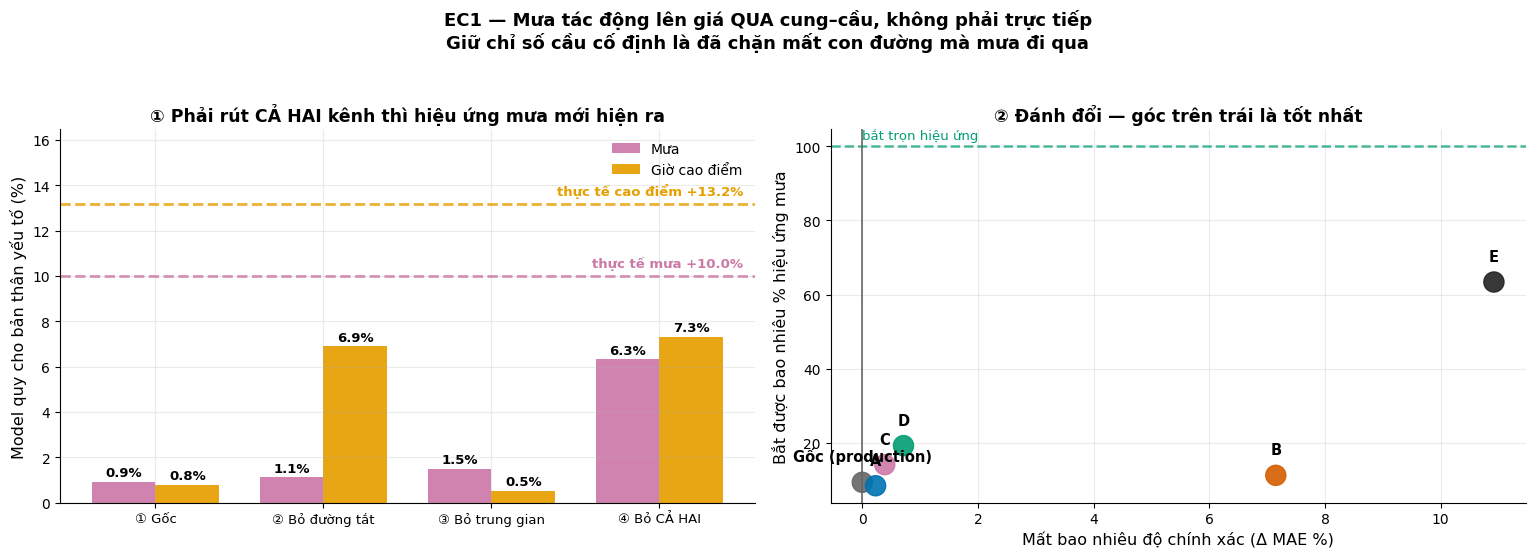

In [7]:
# ═════════ HINH EC1 — hai kenh trung gian ═════════
fig, ax = plt.subplots(1, 2, figsize=(15.5, 5.4))

a = ax[0]
x = np.arange(len(cd)); w = .38
a.bar(x - w/2, cd["PDP mưa"]*100, w, color=PURPLE, alpha=.92, label="Mưa")
a.bar(x + w/2, cd["PDP cao điểm"]*100, w, color=MULT, alpha=.92, label="Giờ cao điểm")
a.axhline(THAT_MUA*100, color=PURPLE, lw=2, ls="--", alpha=.8)
a.axhline(THAT_CD*100,  color=MULT,   lw=2, ls="--", alpha=.8)
a.text(len(cd)-.5, THAT_MUA*100 + .4, f"thực tế mưa {THAT_MUA:+.1%}",
       ha="right", fontsize=9.5, color=PURPLE, fontweight="bold")
a.text(len(cd)-.5, THAT_CD*100 + .4, f"thực tế cao điểm {THAT_CD:+.1%}",
       ha="right", fontsize=9.5, color=MULT, fontweight="bold")
for i in x:
    a.text(i - w/2, cd["PDP mưa"].iloc[i]*100 + .25, f"{cd['PDP mưa'].iloc[i]:.1%}",
           ha="center", fontsize=9.5, fontweight="bold")
    a.text(i + w/2, cd["PDP cao điểm"].iloc[i]*100 + .25, f"{cd['PDP cao điểm'].iloc[i]:.1%}",
           ha="center", fontsize=9.5, fontweight="bold")
a.set_xticks(x); a.set_xticklabels([t.split(" — ")[0].split(" (")[0] for t in cd["Cấu hình"]],
                                   fontsize=9.5)
a.set_ylabel("Model quy cho bản thân yếu tố (%)")
a.set_ylim(0, max(THAT_CD, THAT_MUA)*100*1.25)
a.set_title("① Phải rút CẢ HAI kênh thì hiệu ứng mưa mới hiện ra", fontweight="bold")
a.legend(frameon=False, fontsize=10)

a = ax[1]
mau_bt = [MUT, BASE, RED, PURPLE, GREEN, INK]
a.scatter(bang["Δ MAE"]*100, bang["Bắt được"]*100, s=210, c=mau_bt, alpha=.9, zorder=3)
for _, r in bang.iterrows():
    a.annotate(r["Biến thể"].split(" · ")[0],
               (r["Δ MAE"]*100, r["Bắt được"]*100),
               textcoords="offset points", xytext=(0, 15), ha="center",
               fontsize=10.5, fontweight="bold")
a.axhline(100, color=GREEN, lw=1.8, ls="--", alpha=.7)
a.text(0, 102, "bắt trọn hiệu ứng", fontsize=9.5, color=GREEN)
a.axvline(0, color=MUT, lw=1.2)
a.set_xlabel("Mất bao nhiêu độ chính xác (Δ MAE %)")
a.set_ylabel("Bắt được bao nhiêu % hiệu ứng mưa")
a.set_title("② Đánh đổi — góc trên trái là tốt nhất", fontweight="bold")

fig.suptitle("EC1 — Mưa tác động lên giá QUA cung–cầu, không phải trực tiếp\n"
             "Giữ chỉ số cầu cố định là đã chặn mất con đường mà mưa đi qua",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "EC1_hai_kenh_trung_gian.png")
plt.show()

### Đọc hình EC1 — phát hiện chính của notebook

**Khoảng cách 9 điểm ở `03` không phải lỗi model.** Nó là chênh lệch giữa hai đại lượng khác nhau:

| Đại lượng | Đo bằng | Ý nghĩa |
|---|---|---|
| **Hiệu ứng tổng** | Ghép cặp trên dữ liệu thật | Trời mưa thì giá cuối cùng đổi bao nhiêu — **qua mọi con đường** |
| **Hiệu ứng trực tiếp** | Partial dependence | Đổi mỗi biến thời tiết, **giữ cung–cầu và giá quan sát cố định** |

Mưa làm giá tăng **thông qua** cầu. Giữ chỉ số cầu cố định rồi hỏi *"mưa ảnh hưởng bao nhiêu"* thì
câu trả lời gần 0 là **đúng**, không phải sai.

**Bằng chứng dứt điểm:** rút *một* kênh không đủ — phải rút **cả hai** thì hiệu ứng mới hiện ra.

Hai yếu tố phản ứng khác nhau và điều đó cũng khớp cơ chế:

- **Giờ cao điểm** hiện ra ngay khi bỏ đường tắt, vì `gio_vn` là feature trực tiếp
- **Mưa** chỉ hiện ra khi bỏ cả cung–cầu, vì nó **hoàn toàn** đi qua kênh đó

## 6. Vậy encode causality nghĩa là gì

Câu hỏi không phải *"model có hiểu cơ chế không"* mà là **"muốn model dùng con đường nào"**:

| Muốn gì | Cần cấu hình nào | Cái giá |
|---|---|---|
| **Dự báo chính xác nhất** khi có đủ tín hiệu thị trường | Gốc | — |
| Trả lời **what-if theo cung–cầu** — *"nếu cầu tăng 20% thì sao"* | Gốc *(đã làm được)* | — |
| Trả lời **what-if theo thời tiết** — *"mai mưa thì giá bao nhiêu"* | **E** — bỏ cả hai kênh | mất độ chính xác |
| Ngoại suy an toàn ngoài dải quan sát | **A** — ràng buộc đơn điệu | gần như miễn phí |

**Điểm cần nói rõ với mentor:** model gốc **đã** trả lời được câu what-if quan trọng nhất —
*"cung–cầu đổi thì giá đổi thế nào"* — vì cung–cầu là feature trực tiếp của nó. Đó chính là
*market signal multiplier*.

Cái nó **không** trả lời được là what-if theo **yếu tố nằm thượng nguồn** của cung–cầu, như thời
tiết. Và muốn có khả năng đó thì phải trả giá.

In [8]:
goc = bang.iloc[0]
e   = bang[bang["Biến thể"].str.startswith("E")].iloc[0]
a_  = bang[bang["Biến thể"].str.startswith("A")].iloc[0]
print("So sánh ba lựa chọn đáng cân nhắc:")
print(f"  Gốc : MAE {goc.MAE:>8,.0f}đ · ±{goc['Nửa độ rộng']:.1%} · bắt {goc['Bắt được']:>5.0%} hiệu ứng mưa")
print(f"  A   : MAE {a_.MAE:>8,.0f}đ ({a_['Δ MAE']:+.1%}) · ±{a_['Nửa độ rộng']:.1%} · bắt {a_['Bắt được']:>5.0%}")
print(f"  E   : MAE {e.MAE:>8,.0f}đ ({e['Δ MAE']:+.1%}) · ±{e['Nửa độ rộng']:.1%} · bắt {e['Bắt được']:>5.0%}")

So sánh ba lựa chọn đáng cân nhắc:
  Gốc : MAE   17,983đ · ±29.5% · bắt    9% hiệu ứng mưa
  A   : MAE   18,024đ (+0.2%) · ±29.5% · bắt    8%
  E   : MAE   19,947đ (+10.9%) · ±31.3% · bắt   63%


## Kết luận

### 1. Phát hiện chính — khoảng cách PDP không phải lỗi model

Cách đọc ở `03` (*"model chép giá quan sát chứ không hiểu mưa"*) **quá đơn giản**. Sự thật:

> **Mưa tác động lên giá hoàn toàn thông qua cung–cầu.** Partial dependence giữ cung–cầu cố định
> nên đo được **hiệu ứng trực tiếp** ≈ 0 — điều đó **đúng**, không phải model sai.

Bằng chứng: rút riêng đường tắt hoặc riêng cung–cầu đều không làm hiệu ứng hiện ra. Phải rút **cả
hai** thì mới bắt được phần lớn hiệu ứng.

### 2. Trả lời mentor: *"encode causality sẽ tốt cho accuracy hay uncertainty"*

Đo được rồi, và câu trả lời là **không** trên bộ dữ liệu này:

- Không biến thể nào **vừa** hiểu cơ chế hơn **vừa** chính xác hơn
- Biến thể bắt được nhiều hiệu ứng nhất cũng là biến thể mất nhiều accuracy nhất
- Độ rộng khoảng **không cải thiện** ở bất kỳ biến thể nào

Lý do đã có ở `02` và `04`: model đã chạm **sàn sai số của bộ dữ liệu**, nên không còn dư địa để vừa
thêm ràng buộc vừa giữ độ chính xác.

⇒ Đây là **đánh đổi**, không phải cải thiện. Câu hỏi cho mentor: **team sẵn sàng đổi bao nhiêu
accuracy lấy khả năng what-if theo thời tiết?**

### 3. Khuyến nghị

| | Khuyến nghị | Vì sao |
|---|---|---|
| **Nên làm ngay** | Biến thể **A** — ràng buộc đơn điệu | Gần như miễn phí, model không bao giờ ra phản ứng ngược dấu |
| **Chỉ làm nếu cần what-if thời tiết** | Biến thể **E** | Đắt, và chỉ đáng khi thật sự cần |
| **Không nên** | Biến thể B, C, D | Mất accuracy mà không bắt thêm được bao nhiêu |

### 4. Việc còn nợ

| Việc | Chặn bởi |
|---|---|
| Chốt biến thể đưa vào pipeline | Câu trả lời của mentor về đánh đổi |
| Kiểm biến thể được chọn trên **coverage điều kiện** theo band giá | Sau khi chốt |
| Đo lại toàn bộ nếu có dữ liệu thật | Câu hỏi ⭐ về mức nhiễu |

### Liên quan

| Notebook | Nội dung |
|---|---|
| `03_CETERIS_PARIBUS_VA_CAUSALITY` | Nơi phát hiện khoảng cách 9 điểm — notebook này giải thích nó |
| `04_CAU_THANH_GIA` | Yếu tố nào cấu thành giá |
| `05_DUONG_PHAN_UNG` | Chiều và hình dạng quan hệ — nguồn của ràng buộc đơn điệu |
| `02_IMPROVE_HAY_GIAM_UNCERTAINTY` | Vì sao không còn dư địa accuracy |